In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

pd.set_option("display.max_columns", 200)


In [2]:
from google.colab import files

uploaded = files.upload()


Saving Movies_Cleaned.csv to Movies_Cleaned.csv


In [3]:
from google.colab import files

uploaded = files.upload()


Saving TVShows_Cleaned.csv to TVShows_Cleaned.csv


In [5]:
movies = pd.read_csv("Movies_Cleaned.csv")
tv = pd.read_csv("TVShows_Cleaned.csv")

print("Movies shape:", movies.shape)
print("TV shape:", tv.shape)

movies.head()
tv.head()

Movies shape: (9515, 17)
TV shape: (5368, 17)


,ID,Title,Year,Age,Rotten Tomatoes,Netflix,Hulu,Prime Video,Disney+,Type,Genre,Country,Language,IMDb,IMDb_ID,Age_Min,RottenTomatoes_Score
0,1,Breaking Bad,2008,18+,100/100,1,0,0,0,1,"crime television series, drama television seri...",United States,"American English, Spanish language in the Amer...",10.0,tt0903747,18.0,100
1,2,Stranger Things,2016,16+,96/100,1,0,0,0,1,"science fiction television program, horror tel...",United States,English,9.0,tt4574334,16.0,96
2,3,Attack on Titan,2013,18+,95/100,1,1,0,0,1,reality television,United States,English,9.0/10,tt0092400,18.0,95
3,4,Better Call Saul,2015,18+,94/100,1,0,0,0,1,"legal drama, crime television series",United States,English,10.0,tt3032476,18.0,94
4,5,Dark,2017,16+,93/100,1,0,0,0,1,"science fiction television program, drama tele...",Germany,German,10.0,tt5753856,16.0,93


In [6]:
def overview(df, name):
    print(f"\n==== {name} ====")
    print("Missing values:", df.isna().sum().sum())
    print("Duplicates:", df.duplicated().sum())
    display(df.describe())

overview(movies, "Movies")
overview(tv, "TV Shows")



==== Movies ====
Missing values: 0
Duplicates: 0


,ID,Year,Netflix,Hulu,Prime Video,Disney+,Type,IMDb,Age_Min,RottenTomatoes_Score
count,9515.000000,9515.000000,9515.000000,9515.000000,9515.000000,9515.000000,9515.0,9515.000000,9515.000000,9515.000000
mean,4758.000000,2007.422386,0.388334,0.110037,0.432265,0.096900,0.0,6.720494,15.132738,53.543878
std,2746.888239,19.130367,0.487397,0.312952,0.495417,0.295837,0.0,1.815770,3.229361,13.192884
min,1.000000,1914.000000,0.000000,0.000000,0.000000,0.000000,0.0,1.000000,7.000000,10.000000
25%,2379.500000,2006.000000,0.000000,0.000000,0.000000,0.000000,0.0,6.000000,16.000000,44.000000
50%,4758.000000,2015.000000,0.000000,0.000000,0.000000,0.000000,0.0,7.000000,16.000000,52.000000
75%,7136.500000,2018.000000,1.000000,0.000000,1.000000,0.000000,0.0,7.300000,16.000000,62.000000
max,9515.000000,2021.000000,1.000000,1.000000,1.000000,1.000000,0.0,10.000000,18.000000,98.000000



==== TV Shows ====
Missing values: 0
Duplicates: 0


,ID,Year,Netflix,Hulu,Prime Video,Disney+,Type,Age_Min,RottenTomatoes_Score
count,5368.000000,5368.000000,5368.000000,5368.000000,5368.000000,5368.000000,5368.0,5368.000000,5368.000000
mean,2814.945790,2012.628726,0.367176,0.301975,0.341095,0.065387,1.0,14.919896,47.220380
std,1672.385727,10.142813,0.482080,0.459157,0.474122,0.247231,0.0,3.467906,19.555753
min,1.000000,1904.000000,0.000000,0.000000,0.000000,0.000000,1.0,7.000000,10.000000
25%,1345.750000,2011.000000,0.000000,0.000000,0.000000,0.000000,1.0,16.000000,36.000000
50%,2788.000000,2016.000000,0.000000,0.000000,0.000000,0.000000,1.0,16.000000,48.000000
75%,4308.250000,2018.000000,1.000000,1.000000,1.000000,0.000000,1.0,16.000000,60.000000
max,5717.000000,2021.000000,1.000000,1.000000,1.000000,1.000000,1.0,18.000000,100.000000


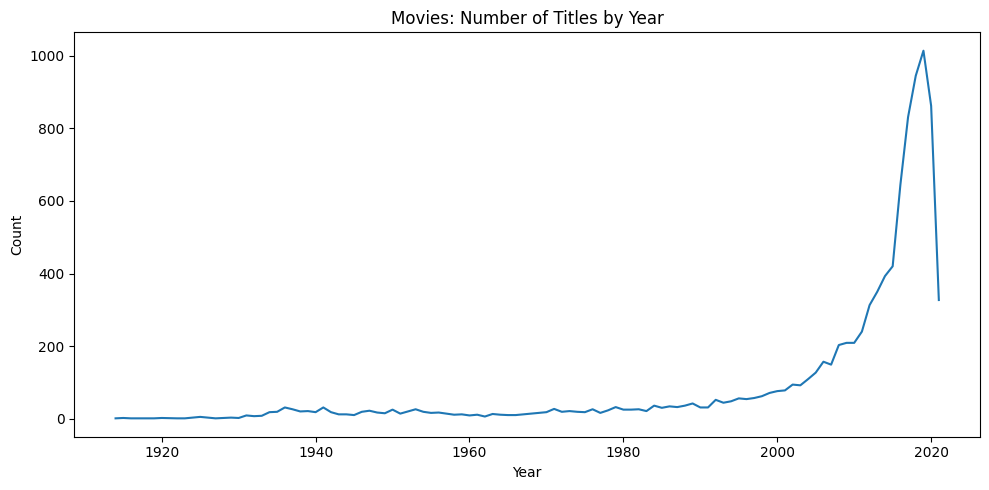

In [12]:
plt.figure(figsize=(10,5))
movies["Year"].value_counts().sort_index().plot()
plt.title("Movies: Number of Titles by Year")
plt.xlabel("Year")
plt.ylabel("Count")
plt.tight_layout()
plt.show()


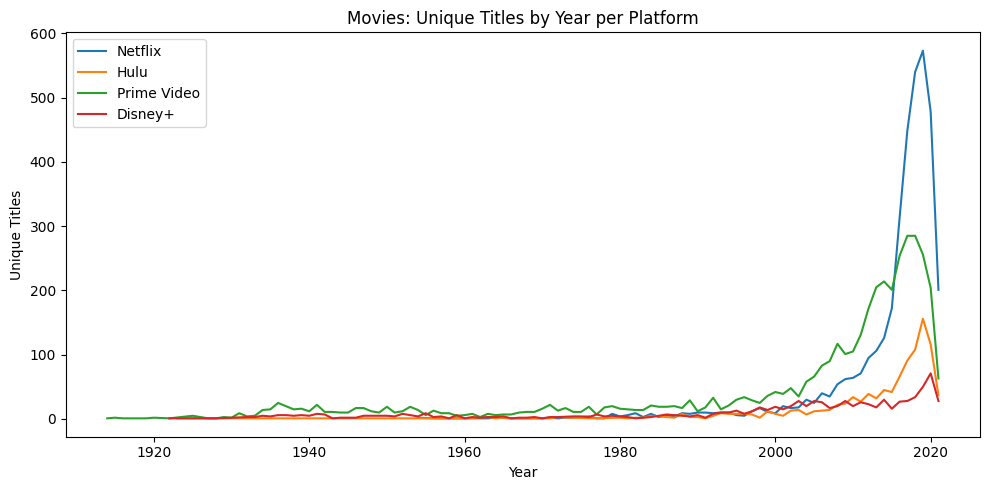

In [13]:
platform_cols = ["Netflix", "Hulu", "Prime Video", "Disney+"]

plt.figure(figsize=(10,5))

for platform in platform_cols:
    subset = movies[movies[platform] == 1]
    counts = subset.groupby("Year")["Title"].nunique()
    plt.plot(counts.index, counts.values, label=platform)

plt.title("Movies: Unique Titles by Year per Platform")
plt.xlabel("Year")
plt.ylabel("Unique Titles")
plt.legend()
plt.tight_layout()
plt.show()


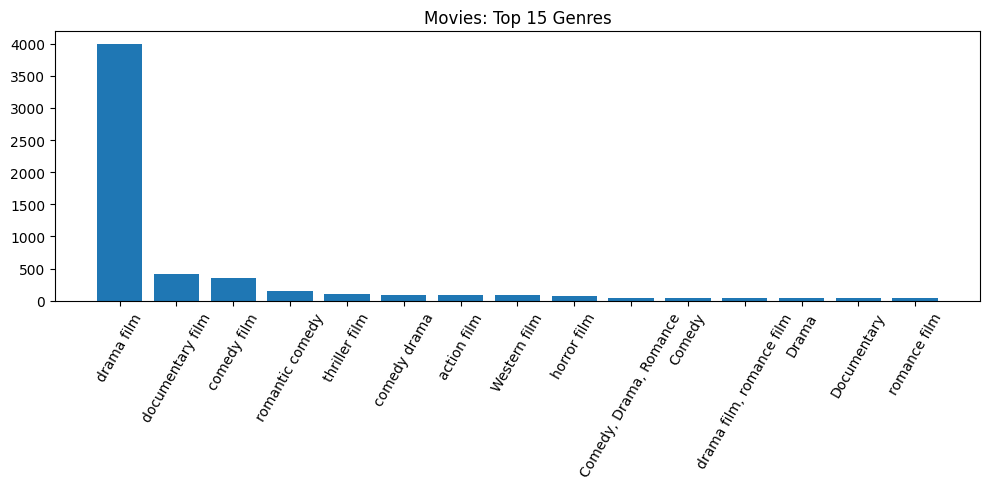

In [14]:
top_genres = movies["Genre"].value_counts().head(15)

plt.figure(figsize=(10,5))
plt.bar(top_genres.index, top_genres.values)
plt.title("Movies: Top 15 Genres")
plt.xticks(rotation=60)
plt.tight_layout()
plt.show()


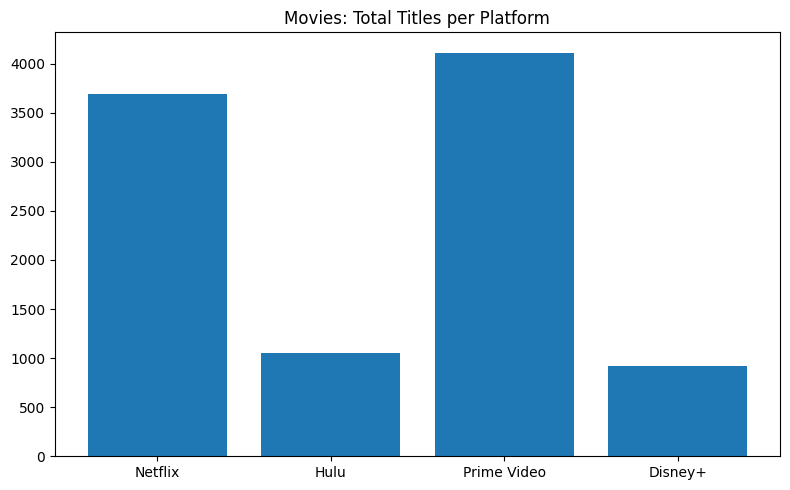

In [15]:
platform_totals = movies[platform_cols].sum()

plt.figure(figsize=(8,5))
plt.bar(platform_totals.index, platform_totals.values)
plt.title("Movies: Total Titles per Platform")
plt.tight_layout()
plt.show()


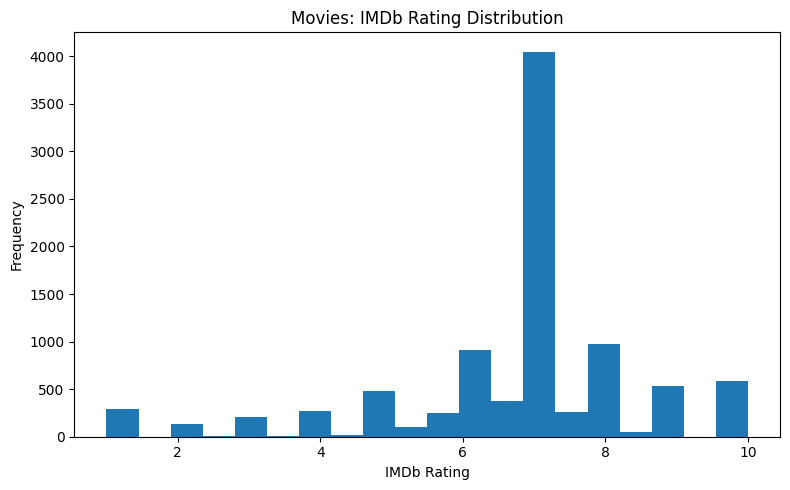

In [16]:
plt.figure(figsize=(8,5))
plt.hist(movies["IMDb"], bins=20)
plt.title("Movies: IMDb Rating Distribution")
plt.xlabel("IMDb Rating")
plt.ylabel("Frequency")
plt.tight_layout()
plt.show()


<Figure size 1000x500 with 0 Axes>

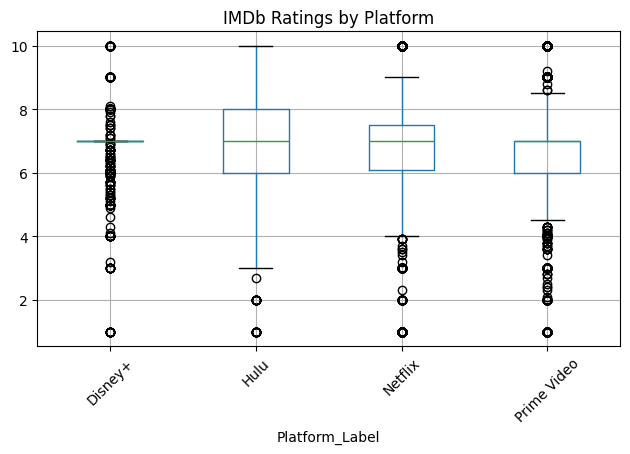

In [17]:
movies["Platform_Label"] = np.select(
    [
        movies["Netflix"] == 1,
        movies["Hulu"] == 1,
        movies["Prime Video"] == 1,
        movies["Disney+"] == 1
    ],
    ["Netflix", "Hulu", "Prime Video", "Disney+"],
    default="Other"
)

plt.figure(figsize=(10,5))
movies.boxplot(column="IMDb", by="Platform_Label")
plt.title("IMDb Ratings by Platform")
plt.suptitle("")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()


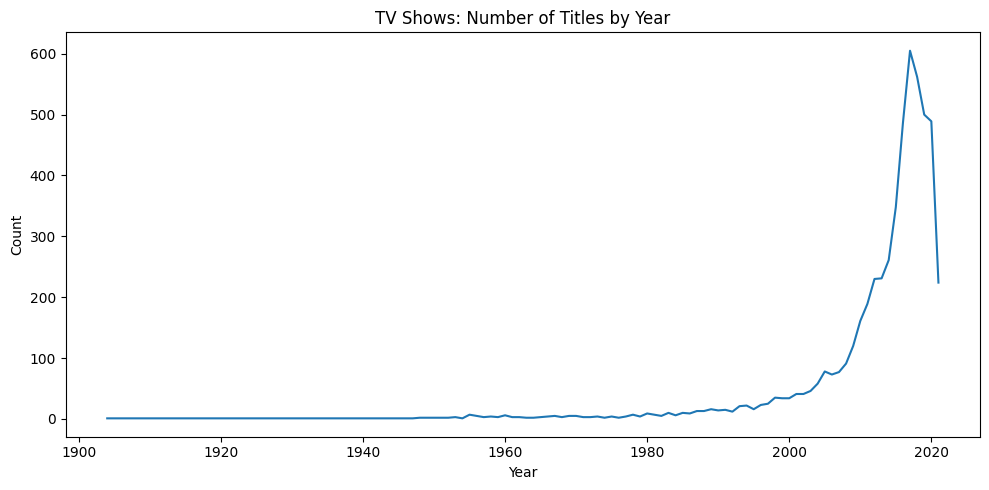

In [18]:
plt.figure(figsize=(10,5))
tv["Year"].value_counts().sort_index().plot()
plt.title("TV Shows: Number of Titles by Year")
plt.xlabel("Year")
plt.ylabel("Count")
plt.tight_layout()
plt.show()


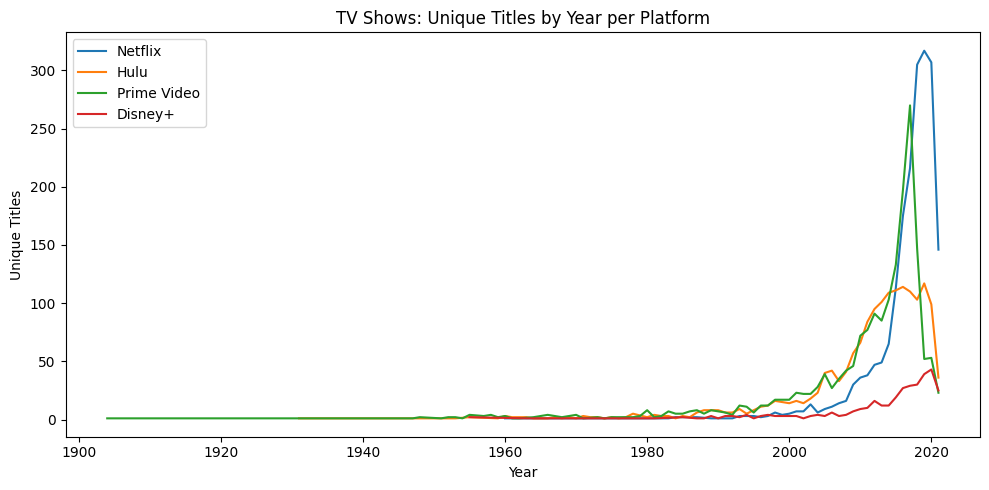

In [19]:
plt.figure(figsize=(10,5))

for platform in platform_cols:
    subset = tv[tv[platform] == 1]
    counts = subset.groupby("Year")["Title"].nunique()
    plt.plot(counts.index, counts.values, label=platform)

plt.title("TV Shows: Unique Titles by Year per Platform")
plt.xlabel("Year")
plt.ylabel("Unique Titles")
plt.legend()
plt.tight_layout()
plt.show()


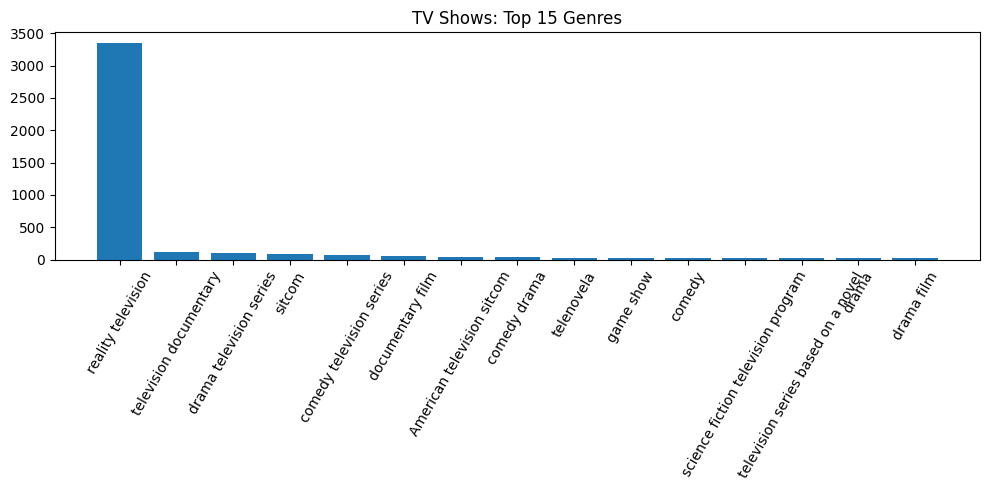

In [20]:
top_tv_genres = tv["Genre"].value_counts().head(15)

plt.figure(figsize=(10,5))
plt.bar(top_tv_genres.index, top_tv_genres.values)
plt.title("TV Shows: Top 15 Genres")
plt.xticks(rotation=60)
plt.tight_layout()
plt.show()


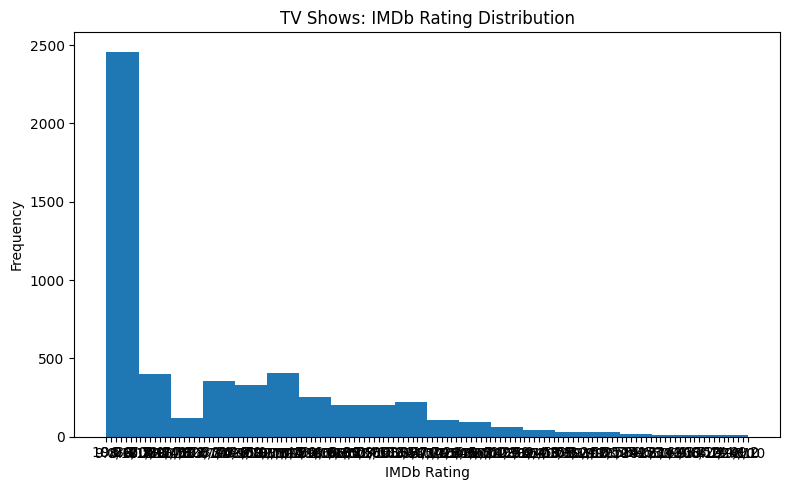

In [21]:
plt.figure(figsize=(8,5))
plt.hist(tv["IMDb"], bins=20)
plt.title("TV Shows: IMDb Rating Distribution")
plt.xlabel("IMDb Rating")
plt.ylabel("Frequency")
plt.tight_layout()
plt.show()


Most Surprising Trend

The rapid growth in titles after 2015 highlights the expansion of streaming services and content production.

Best Business Story

The multi-line platform chart clearly shows how platforms differ in growth strategy over time.

What I Would Explore Next

I would compare average IMDb ratings by platform and genre trends over time to analyze quality vs quantity strategies.